### Data Exploration, Cleaning, and sample comparisons.  

In [2]:
# Import needed libraries and check current working directory. 
import os
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.weightstats import ttest_ind as sm_ttest
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns
import matplotlib.pyplot as plt
os.getcwd()

'c:\\Users\\thefi\\OneDrive\\Desktop\\2 - DS 6021 Predictive Modeling\\DS6021-Predictive_Modeling\\notebooks'

### Two sample t-test

We will use data from the Palmer Penguins dataset to explore how to compare two means. This data contains body measurements for 344 penguins of three species, collected at the Palmer Station Long Term Ecological Research site in Antarctica. 

Note: There is a Palmer Penguins package that is available in Python and you can install and manage it as part of your environment. This is optional and you do not have to do this. I've downloaded this dataset and put it in the data folder since that is how we will mostly do things going forward.  

In [3]:
# First, we always want to pull the data and take a look at it. 

peng = pd.read_csv("../data/penguins.csv")
print(peng.shape)
peng.head()

(344, 8)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [4]:
# The first question we want to ask is:
# Is there an appreciable difference in body mass between male and female penguins. 

# There is some missing data above. Let's explore this a bit more. 
print(peng.isna().sum())
print()
print(peng["sex"].value_counts(dropna=False))


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

sex
male      168
female    165
NaN        11
Name: count, dtype: int64


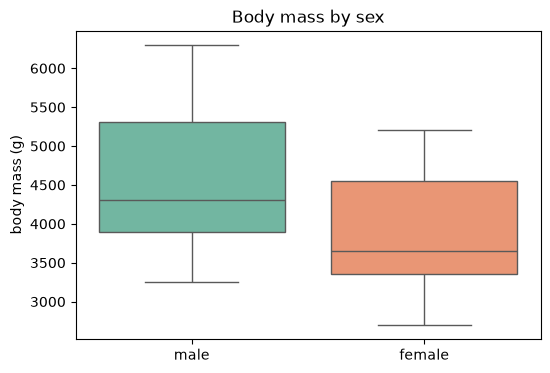

In [5]:
# First, let's visualize this data before computing a T-test

plt.figure(figsize=(6, 4))
sns.boxplot(
    data=peng.dropna(subset=["sex"]),
    x="sex",
    y="body_mass_g",
    hue="sex",
    palette="Set2",
    legend=False
)
plt.xlabel("")
plt.ylabel("body mass (g)")
plt.title("Body mass by sex")
plt.show()

In [6]:
# There are 11 penguins where we don't know if they are male or female, so we'll drop those
# from our analysis. 

# First we want to compute mean male and female body masses, and use the scipy stats package to compute a t-test. 

male_mass = peng.loc[peng["sex"] == "male", "body_mass_g"].dropna()
female_mass = peng.loc[peng["sex"] == "female", "body_mass_g"].dropna()

# Note that we are assuming our measurements do not have equal variance, which is why we are using the equal_var=False argument
# You should always look at function documentation if you are unsure about defaults
# In this case it can be found here: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html
t_stat, p_value = stats.ttest_ind(male_mass, female_mass, equal_var=False)

print("mean body mass, male:  ", round(male_mass.mean(), 1), " n =", len(male_mass))
print("mean body mass, female:", round(female_mass.mean(), 1), " n =", len(female_mass))
print("t-statistic:", round(t_stat, 3))
print("p-value:", p_value)


mean body mass, male:   4545.7  n = 168
mean body mass, female: 3862.3  n = 165
t-statistic: 8.555
p-value: 4.793891255051507e-16


In [7]:
# Note that we could also use the statsmodels package to do this calculation. 
# The arguments are different (e.g. usvar='unequal' vs equal_var=False) and there is an additional return variable but the result is the same
# Function documentation: https://www.statsmodels.org/stable/generated/statsmodels.stats.weightstats.ttest_ind.html

t_stat, p_value, df = sm_ttest(male_mass, female_mass, usevar='unequal')

print("mean body mass, male:  ", round(male_mass.mean(), 1), " n =", len(male_mass))
print("mean body mass, female:", round(female_mass.mean(), 1), " n =", len(female_mass))
print("t-statistic:", round(t_stat, 3))
print("p-value:", p_value)

mean body mass, male:   4545.7  n = 168
mean body mass, female: 3862.3  n = 165
t-statistic: 8.555
p-value: 4.793891255051459e-16


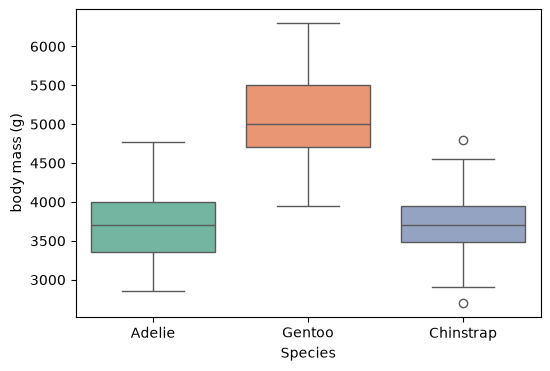

In [8]:
# We just looked at whether body mass would vary significantly between males and females.
# Now let's look at whether body mass varies significantly between Adelie and Chinstrap penguins. 
# We are going to ignore Gentoo for the moment.

# First, let's plot this to get a visual. 

plt.figure(figsize=(6, 4))
sns.boxplot(
    data=peng.dropna(subset=["species"]),
    x="species",
    y="body_mass_g",
    hue="species",
    palette="Set2",
    legend=False
)
plt.xlabel("Species")
plt.ylabel("body mass (g)")
plt.show()

In [9]:
# Visually, there does not seem to be a difference in average body mass between Adelie and Chinstrap penguins.
# Let's do a t-test to be sure

adelie = peng.loc[peng["species"] == "Adelie", "body_mass_g"].dropna()
chinstrap = peng.loc[peng["species"] == "Chinstrap", "body_mass_g"].dropna()

t_stat, p_value = stats.ttest_ind(adelie, chinstrap, equal_var=False)

print("   Adelie:   ", round(adelie.mean(), 1))
print("   Chinstrap:", round(chinstrap.mean(), 1))
print("   t =", round(t_stat, 3), "  p =", p_value)
print()

   Adelie:    3700.7
   Chinstrap: 3733.1
   t = -0.543   p = 0.5878608159584936



### Analysis of Variance

Now let's look at comparing more than one mean using analysis of variance (ANOVA)

In [10]:
# Previously, we compared only the Adelie and Chinstrap penguins to see if they had an appreciable difference in body mass.
# The goal of ignorging Gentoo in the above calculation was to show the type of p-value you get when there is no difference to speak of.
# The correct way to do this is to compare all three means using an ANOVA.

# Remember from our lecture notes that equal variance is an assumption for ANOVA
# Let's check the equal variance assumption before calculating. 

peng_anova = peng.dropna(subset=["body_mass_g", "species"])
print(peng_anova.groupby("species")["body_mass_g"].agg(["count", "mean", "std"]).round(2))

groups = [peng_anova.loc[peng_anova["species"] == s, "body_mass_g"]
          for s in ["Adelie", "Chinstrap", "Gentoo"]]

print("Levene's test p-value:", round(stats.levene(*groups).pvalue, 4))

           count     mean     std
species                          
Adelie       151  3700.66  458.57
Chinstrap     68  3733.09  384.34
Gentoo       123  5076.02  504.12
Levene's test p-value: 0.0064


In [11]:
# Because the p-value above is significant, this means that these three penguin species do NOT have equal variance in their body mass. 
# Remember: the p-value indicates the null hypothesis--equal variance--is rejected)
# This means that ANOVA is not appropriate for this analysis.

# Let's look instead at a different variable, bill depth. 

peng_anova = peng.dropna(subset=["bill_depth_mm", "species"])
print(peng_anova.groupby("species")["bill_depth_mm"].agg(["count", "mean", "std"]).round(2))

groups = [peng_anova.loc[peng_anova["species"] == s, "bill_depth_mm"]
          for s in ["Adelie", "Chinstrap", "Gentoo"]]

print("Levene's test p-value:", round(stats.levene(*groups).pvalue, 4))

           count   mean   std
species                      
Adelie       151  18.35  1.22
Chinstrap     68  18.42  1.14
Gentoo       123  14.98  0.98
Levene's test p-value: 0.132


In [12]:
# The null hypothesis (equal variance) is supported. Let's do the ANOVA

model = ols("bill_depth_mm ~ C(species)", data=peng_anova).fit()
print(sm.stats.anova_lm(model, typ=2))

# This result telss us that there is a signficant difference among the groups, but it does not tell us between which groups the difference is significant. 
# The F-statistic tells us that the between group difference is larger than the within group difference. 

                sum_sq     df           F        PR(>F)
C(species)  903.967209    2.0  359.789149  1.507658e-84
Residual    425.867324  339.0         NaN           NaN


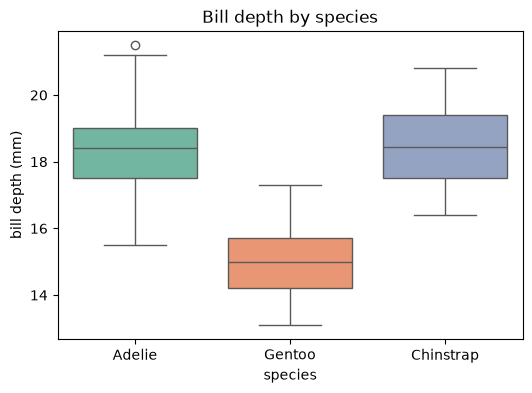

In [13]:
# Now let's plot bill depth as a function of species. 

plt.figure(figsize=(6, 4))
sns.boxplot(data=peng_anova, x="species", y="bill_depth_mm",
            hue="species", palette="Set2", legend=False)
plt.ylabel("bill depth (mm)")
plt.title("Bill depth by species")
plt.show()

In [14]:
# In order to tell which pairs have significant differences, we will use the TukeyHSD test. 

tukey_result = pairwise_tukeyhsd(peng_anova["bill_depth_mm"], peng_anova["species"], alpha=0.05)
print(tukey_result)

   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
   Adelie Chinstrap   0.0742 0.8929 -0.3111  0.4596  False
   Adelie    Gentoo  -3.3642    0.0 -3.6847 -3.0438   True
Chinstrap    Gentoo  -3.4385    0.0 -3.8372 -3.0398   True
----------------------------------------------------------


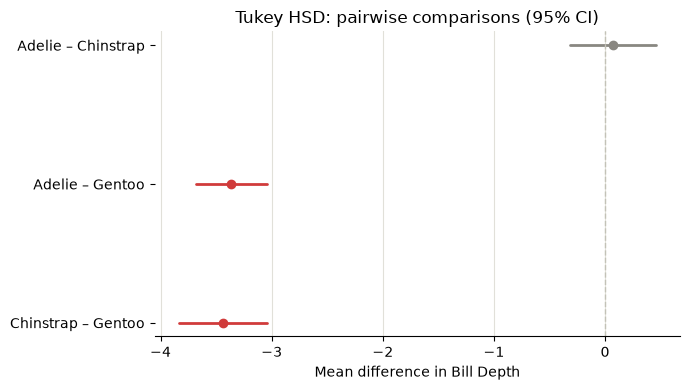

In [15]:
# Visualize the Tukey HSD results

# Convert Tukey HSD results to a DataFrame
tukey_df = pd.DataFrame(
    data=tukey_result._results_table.data[1:],
    columns=tukey_result._results_table.data[0]
)
tukey_df["comparison"] = tukey_df["group1"] + " – " + tukey_df["group2"]

fig, ax = plt.subplots(figsize=(7, 4))

sig_color = "#d03b3b"      # significant (reject H0)
nonsig_color = "#898781"   # not significant

colors = tukey_df["reject"].map({True: sig_color, False: nonsig_color})

for i, row in tukey_df.iloc[::-1].reset_index(drop=True).iterrows():
    color = sig_color if row["reject"] else nonsig_color
    ax.plot(
        [row["lower"], row["upper"]], [i, i],
        color=color, linewidth=2, solid_capstyle="round"
    )
    ax.plot(row["meandiff"], i, "o", color=color, markersize=6)

ax.axvline(0, color="#c3c2b7", linewidth=1, linestyle="--")
ax.set_yticks(range(len(tukey_df)))
ax.set_yticklabels(tukey_df["comparison"][::-1])
ax.set_xlabel("Mean difference in Bill Depth")
ax.set_title("Tukey HSD: pairwise comparisons (95% CI)")

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.grid(axis="x", color="#e1e0d9", linewidth=0.8)

plt.tight_layout()
plt.show()

### Exploring Class Data

Let's take some of the concepts we learned above and apply them to our class data. 

In [16]:
# Read in data frame and look at first few rows
df = pd.read_csv('../data/DS6021-Fall26-Anonymized.csv')
df.head()

,Timestamp,What was your undergraduate major?,What type of phone do you have?,How many years ago did you receive your undergraduate degree?,How many hours do you sleep in a typical night?,Rate your proficiency with git/github,Rate your proficiency with Python,Have you ever used SQL?,What is your favorite sport to watch on tv?,What is your ideal outdoor temperature (in Fahrenheit)?,How many US states have you visited?,What is your favorite season?
0,8/25/2026 8:20:43,Psychology,iPhone,4-6 years,8,3,2,Yes,F1 motorsport,70,8,Fall
1,8/25/2026 9:35:51,Statistics,iPhone,1-3 years,8,3,4,Yes,NaN,70,16,Fall
2,8/25/2026 13:43:23,Economics-Business and Applied Mathematics,iPhone,< 1 year,8,3,3,No,Baseball,70,27,Fall
3,8/25/2026 15:11:38,Data Science (concentration in Computer Science),iPhone,< 1 year,8,3,4,Yes,Football (go Bears!),73,9,Fall
4,8/25/2026 15:26:11,Math and Physics,iPhone,1-3 years,8,2,4,Yes,Figure Skating,73,26,Fall


In [17]:
# Let's look at number of hours slept per night vs time since undergrad. 
# First we are going to rename the columns to something more manageable

df_sleep = df[[
    "How many years ago did you receive your undergraduate degree?",
    "How many hours do you sleep in a typical night?"
]].rename(columns={
    "How many years ago did you receive your undergraduate degree?": "years_since_undergrad",
    "How many hours do you sleep in a typical night?": "sleep_hrs"
})

print(df_sleep.head())
print()
print(df_sleep.isna().sum())

  years_since_undergrad sleep_hrs
0             4-6 years         8
1             1-3 years         8
2              < 1 year         8
3              < 1 year         8
4             1-3 years         8

years_since_undergrad    0
sleep_hrs                0
dtype: int64


In [18]:
# In looking at the unique values, we can see that the data for sleep is MESSY. 
df_sleep["sleep_hrs"].unique()

<ArrowStringArray>
[                                            '8',
                                             '7',
                                           '6-7',
                                             '9',
                                             '5',
                                           '8-9',
                                           '6-8',
                                           '7-9',
 '4-5 if I am lucky, I’m a diagnosed insomniac ',
                                        '8 to 9',
                                           '7.5',
                                             '6',
                                           '5.5',
                                          '6-10',
                                           '7-8',
                                       '6 hours',
                                         '8-9.5',
                                          '8-10',
                                           '8.5',
                               

In [19]:
# Let's clean up sleep hours and properly categorize years since undergrad.
year_order = ["< 1 year", "1-3 years", "4-6 years", "7-10 years", "10+ years"]
df_sleep["years_since_undergrad"] = pd.Categorical(
    df_sleep["years_since_undergrad"], categories=year_order, ordered=True
)

# Average the first two numbers in each response: '6-7' -> 6.5, 'about 7 sometimes 8' -> 7.5
# Note: This is an example of the types of assumptions I wanted you to think through in Lab 0. 
bounds = df_sleep["sleep_hrs"].str.extractall(r"(\d+\.?\d*)")[0].astype(float)
df_sleep["sleep_hrs"] = bounds.groupby(level=0).agg(lambda x: x.head(2).mean())

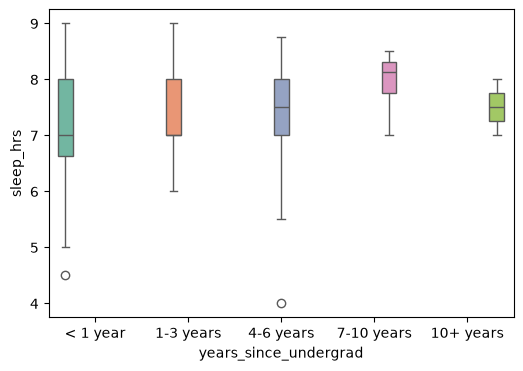

In [20]:
# Now let's plot number of hours of sleep as a function of years since undergrad


plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df_sleep,
    x="years_since_undergrad",
    y="sleep_hrs",
    hue="years_since_undergrad",
    palette="Set2"
)

plt.xlabel("years_since_undergrad")
plt.ylabel("sleep_hrs")
plt.show()

In [21]:
# Should we do an ANOVA on this data? Let's first check for equal variance. 
yrs = ['< 1 year', '1-3 years', '4-6 years', '10+ years', '7-10 years']
print(df_sleep.groupby("years_since_undergrad")["sleep_hrs"].agg(["count", "mean", "std"]).round(2))

groups = [df_sleep.loc[df_sleep["years_since_undergrad"] == s, "sleep_hrs"]
          for s in yrs]

print("Levene's test p-value:", round(stats.levene(*groups).pvalue, 4))

                       count  mean   std
years_since_undergrad                   
< 1 year                  50  7.07  0.98
1-3 years                 17  7.41  0.85
4-6 years                 13  7.25  1.34
7-10 years                 4  7.94  0.66
10+ years                  2  7.50  0.71
Levene's test p-value: 0.6055


In [22]:
# Although the Levene's test demonstrates that there is equal variance, note that 
# the group sizes for 7-10 and 10+ years are sufficiently small that we need to proceed with caution
model = ols("sleep_hrs ~ C(years_since_undergrad)", data=df_sleep).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

# This indicates that there is not a meaningful difference in sleep hours when we look at years since undergrad. 
# That said, there are some other problems with using ANOVA here, and we will explore those more in the homework. 


                             sum_sq    df       F    PR(>F)
C(years_since_undergrad)   3.975827   4.0  0.9828  0.421696
Residual                  81.919522  81.0     NaN       NaN


In [23]:
# Now let's look at favorite season and ideal temperature

# First let's subset the dataframe to look at just those two columns. 
# We will also rename the columns to something less unwieldy. 

df_subset = df[[
    "What is your favorite season?",
    "What is your ideal outdoor temperature (in Fahrenheit)?"
]].rename(columns={
    "What is your favorite season?": "fav_season",
    "What is your ideal outdoor temperature (in Fahrenheit)?": "ideal_temp"
})

df_subset.head()

,fav_season,ideal_temp
0,Fall,70
1,Fall,70
2,Fall,70
3,Fall,73
4,Fall,73


In [24]:
# Let's explore and clean the dataset a little bit
# As with sleep, the data are messy. 

df_subset["ideal_temp"].describe()

count     86
unique    30
top       70
freq      12
Name: ideal_temp, dtype: object

In [25]:
df_subset["ideal_temp"].unique()

<ArrowStringArray>
[               '70',                '73',        '70 degrees',
                '55',                '64',                '75',
                '68',                '65',             '70-85',
                '78',                '80',                '85',
                '74',                '72',        '63 degrees',
                '77',                '76',              '70's',
                '71',                '57',                '79',
      'High sixties',                '40',                '67',
                '60', '75 slightly sunny',              '75 F',
          'Mid 70's',        '40 degrees',                '63']
Length: 30, dtype: str

In [26]:
# We can make a couple of different assumptions about the data.
# You might have chosen differently, I'm going to do the following mappings:

word_to_number = {
    "High sixties": 68,
    "Mid 70's": 75,
    "70-85": 77
}

# I will then remove all non-numeric values from the remaining variables and convert this to a float. 

df_subset["ideal_temp"] = (
    df_subset["ideal_temp"]
    .replace(word_to_number)
    .astype(str)
    .str.extract(r"(\d+\.?\d*)")[0]
    .astype(float)
)

df_subset["ideal_temp"].unique()

array([70., 73., 55., 64., 75., 68., 65., 77., 78., 80., 85., 74., 72.,
       63., 76., 71., 57., 79., 40., 67., 60.])

In [27]:
df_subset["ideal_temp"].describe()

count    86.000000
mean     70.197674
std       7.319305
min      40.000000
25%      68.000000
50%      70.000000
75%      75.000000
max      85.000000
Name: ideal_temp, dtype: float64

In [28]:
df_subset["fav_season"].value_counts()

fav_season
Fall      42
Spring    23
Summer    13
Winter     8
Name: count, dtype: int64

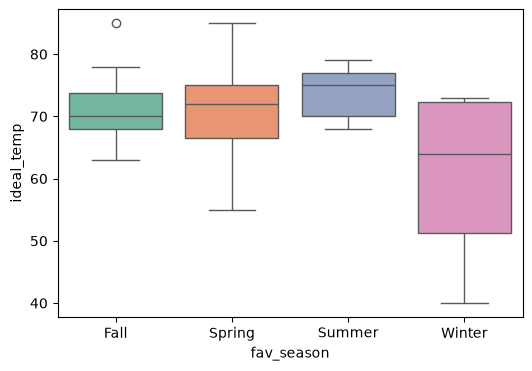

In [29]:
# Now let's plot favorite season and ideal temperature


plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df_subset,
    x="fav_season",
    y="ideal_temp",
    hue="fav_season",
    palette="Set2"
)

plt.xlabel("fav_season")
plt.ylabel("ideal_temp")
plt.show()

In [30]:
print(df_subset.groupby("fav_season")["ideal_temp"].agg(["count", "mean", "std"]).round(2))

groups = [df_subset.loc[df_subset["fav_season"] == s, "ideal_temp"]
          for s in ["Fall", "Spring", "Summer", "Winter"]]

print("Levene's test p-value:", round(stats.levene(*groups).pvalue, 5))

            count   mean    std
fav_season                     
Fall           42  70.52   4.58
Spring         23  70.87   7.19
Summer         13  74.15   3.60
Winter          8  60.12  13.99
Levene's test p-value: 2e-05


In [31]:
#An analysis of variance is not correct in this instance, because the equal variance assumption is violated. 
# We can run the ANOVA, but we need to be very suspicious of the results. 

model = ols("ideal_temp ~ C(fav_season)", data=df_subset).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                    sum_sq    df         F    PR(>F)
C(fav_season)  1029.987341   3.0  7.989718  0.000098
Residual       3523.652194  82.0       NaN       NaN


 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
  Fall Spring   0.3458  0.997  -4.1136  4.8051  False
  Fall Summer     3.63 0.3076  -1.8262  9.0862  False
  Fall Winter -10.3988 0.0005 -17.0305 -3.7672   True
Spring Summer   3.2843  0.476  -2.6809  9.2494  False
Spring Winter -10.7446 0.0008 -17.8009 -3.6882   True
Summer Winter -14.0288    0.0 -21.7539 -6.3038   True
-----------------------------------------------------


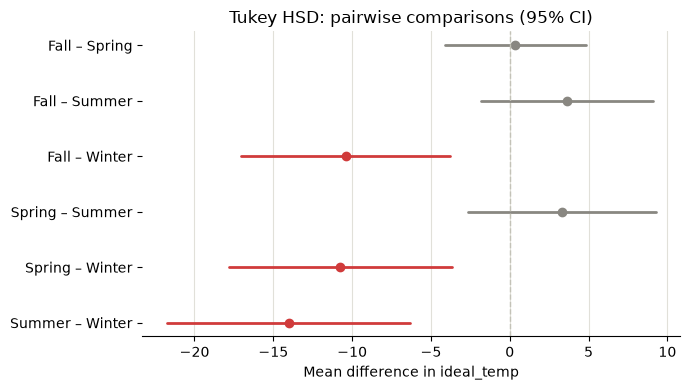

In [32]:
# Similarly for the Tukey test

tukey_result = pairwise_tukeyhsd(
    endog=df_subset["ideal_temp"],
    groups=df_subset["fav_season"],
    alpha=0.05
)

print(tukey_result)

# We can visualize the Tukey HSD results - but again, we take them with a large grain of salt

tukey_df = pd.DataFrame(
    data=tukey_result._results_table.data[1:],
    columns=tukey_result._results_table.data[0]
)
tukey_df["comparison"] = tukey_df["group1"] + " – " + tukey_df["group2"]

fig, ax = plt.subplots(figsize=(7, 4))

sig_color = "#d03b3b"      # significant (reject H0)
nonsig_color = "#898781"   # not significant

colors = tukey_df["reject"].map({True: sig_color, False: nonsig_color})

for i, row in tukey_df.iloc[::-1].reset_index(drop=True).iterrows():
    color = sig_color if row["reject"] else nonsig_color
    ax.plot(
        [row["lower"], row["upper"]], [i, i],
        color=color, linewidth=2, solid_capstyle="round"
    )
    ax.plot(row["meandiff"], i, "o", color=color, markersize=6)

ax.axvline(0, color="#c3c2b7", linewidth=1, linestyle="--")
ax.set_yticks(range(len(tukey_df)))
ax.set_yticklabels(tukey_df["comparison"][::-1])
ax.set_xlabel("Mean difference in ideal_temp")
ax.set_title("Tukey HSD: pairwise comparisons (95% CI)")

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.grid(axis="x", color="#e1e0d9", linewidth=0.8)

plt.tight_layout()
plt.show()